# Advanced Machine Learning Project - Easy Visa

#### Context
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


#### Objective
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

#### Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

- case_id: ID of each visa application
- continent: Information of continent the employee
- education_of_employee: Information of education of the employee
- has_job_experience: Does the employee has any job experience? Y= Yes; N = No
- requires_job_training: Does the employee require any job training? Y = Yes; N = No
- no_of_employees: Number of employees in the employer's company
- yr_of_estab: Year in which the employer's company was established
- region_of_employment: Information of foreign worker's intended region of employment in the US.
- prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to - other workers offering the same or similar service in the same area of employment.
- unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
- case_status: Flag indicating if the Visa was certified or denied

## Import Libraries

In [0]:
# Installing XGBoost package
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading Data

In [0]:
# Read the data from Storage

import os
file_path = os.path.abspath('/Workspace/Users/shaurya.rawat@ukg.com/GreatLearning/1.2 - Machine Learning/Storage/EasyVisa.csv')
visaData = pd.read_csv(file_path, on_bad_lines='skip')

In [0]:
# Check the data shape
visaData.shape

(25480, 12)

## Data Overview

In [0]:
# Creating the copy of data
data = visaData.copy()

In [0]:
# Checking the top 5 rows
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [0]:
# check the bottom 5 rows
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [0]:
# check how no of certified and denied cases
data['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [0]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- There are total of 12 columns and 25480 observations in the dataset
- There are no null values in dataset

In [0]:
# Checking for the null value in the dataset
data.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [0]:
# Checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [0]:
# check for unique values
data.nunique()

case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64

- Case ID is primary key of Visa applicant, which can be dropped from dataset 
- no_of_employees, yr_of_estab, prevailing_wage are the continuous variables
- All other variables are categorical

In [0]:
# Dropping the primary key as it is not required as feature and does not add value
data = data.drop('case_id', axis=1)

In [0]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


In [0]:
# Check statistical information
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


- no_of_employees has negative value (-26) which must be fixed
- prevailing_wage has value of 2.1 as minimum which needs to be explored

## Exploratory Data Analysis

### Univariate analysis

In [0]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

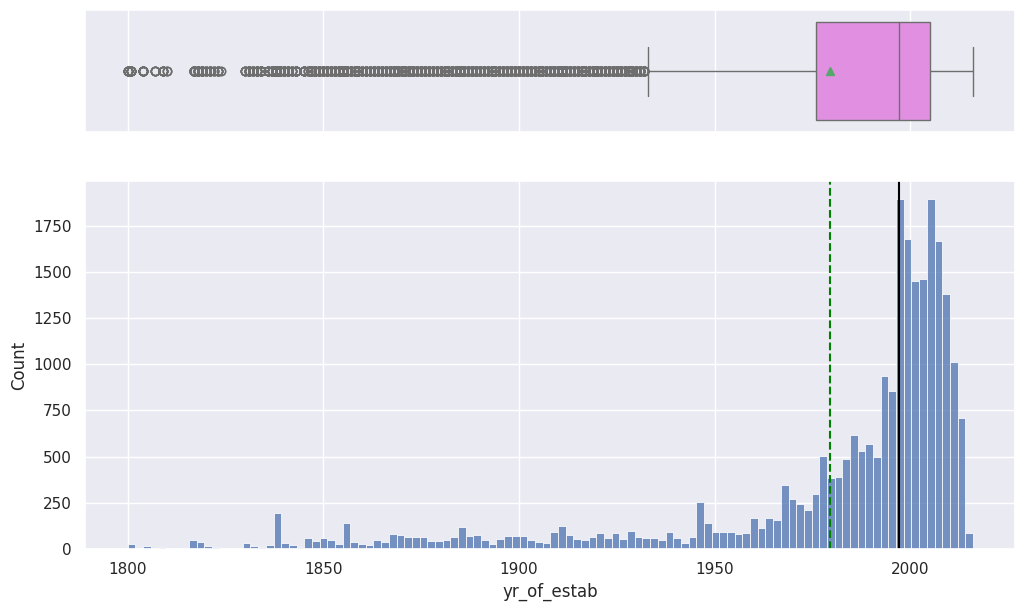

In [0]:
# Observations on yr_of_estab
histogram_boxplot(data, "yr_of_estab")

- Average of year established is 1975
- many companies have heritage of 100-200 years 

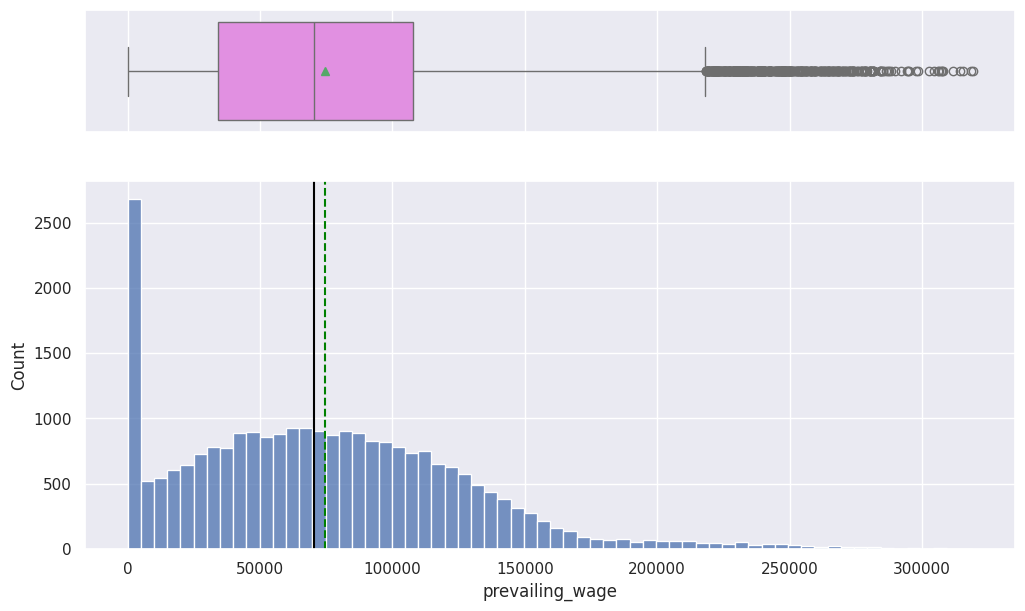

In [0]:
# Observations on prevailing_wage
histogram_boxplot(data, "prevailing_wage")

- Avergae salary is $ 70K
- 3000 records have 0 wage, which is a concern for minimum wage


In [0]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

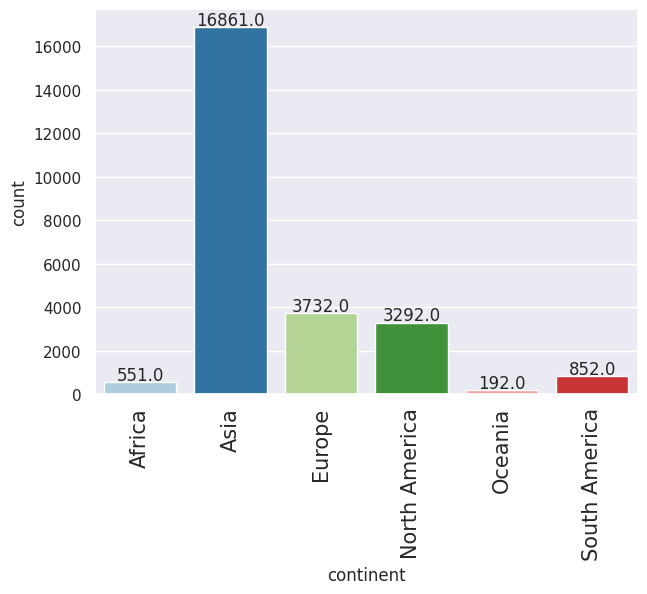

In [0]:
# observations on continent
labeled_barplot(data, "continent")

- Asia has highest no of Visa application
- Europe and North america have 2nd highest visa application
- Oceania has least no of applicantions

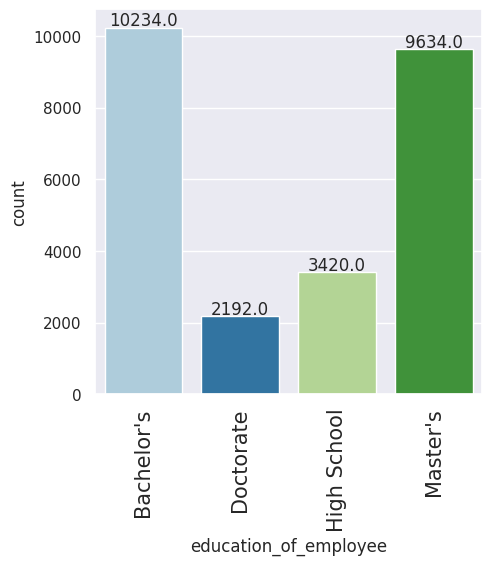

In [0]:
# observations on education_of_employee
labeled_barplot(data, "education_of_employee")

- Most of the applicant have bachelor's or masters degree
- Very few High school or doctorate applying for visa

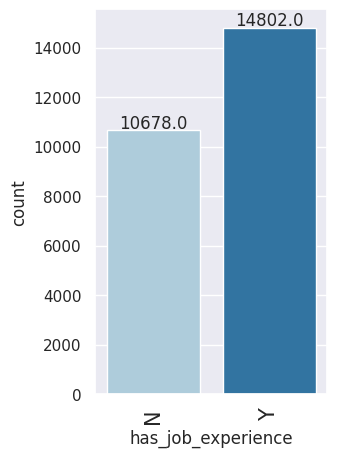

In [0]:
# observations on has_job_experience
labeled_barplot(data, "has_job_experience")

- Mostly applicants have job experience

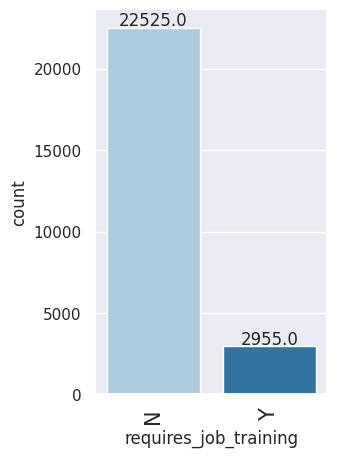

In [0]:
# observations on requires_job_training
labeled_barplot(data, "requires_job_training")

- Most of the applicant don't require job training

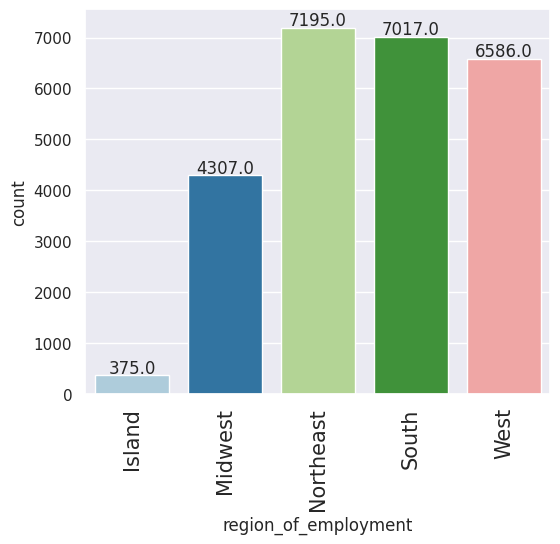

In [0]:
# observations on region_of_employment
labeled_barplot(data, "region_of_employment")

- Northeast region has more applicants, followed by South and West
- Midwest has 50% less applicants
- Island has only 375 - least no of applicants

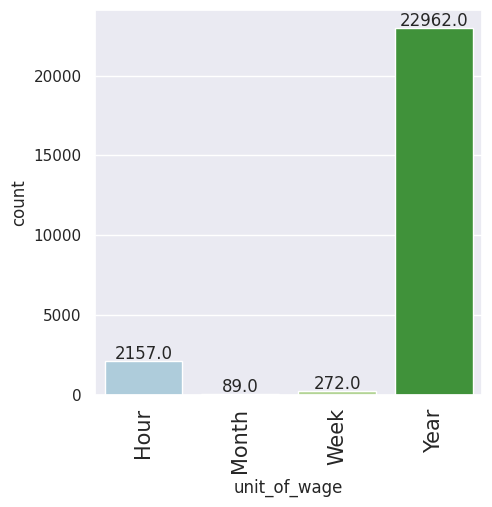

In [0]:
# observations on unit_of_wage
labeled_barplot(data, "unit_of_wage")

- 90% of wages are Yearly
- Very few cases of monthly and weekly wages
- 2157 applicants working in hourly wage  

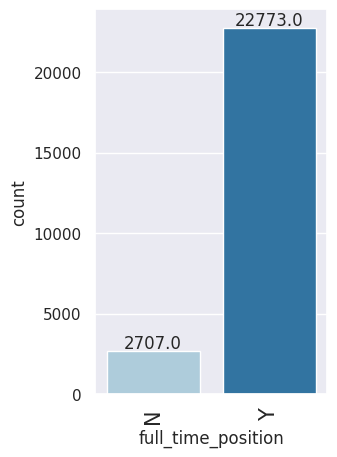

In [0]:
# observations on full_time_position
labeled_barplot(data, "full_time_position")

- Most of the applicant have worked Full-time ~ 90%
- 10% applicant are not full-time

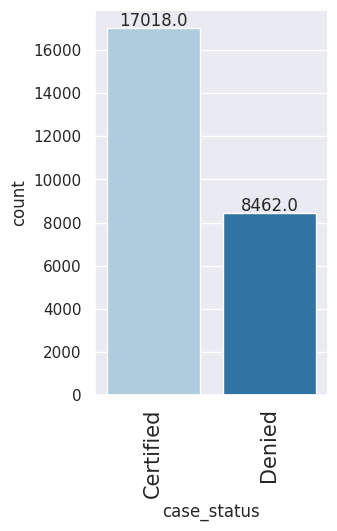

In [0]:
# observations on case_status
labeled_barplot(data, "case_status")

- 67% of applicants are certified and 33% are denied

### Bivariate Analysis

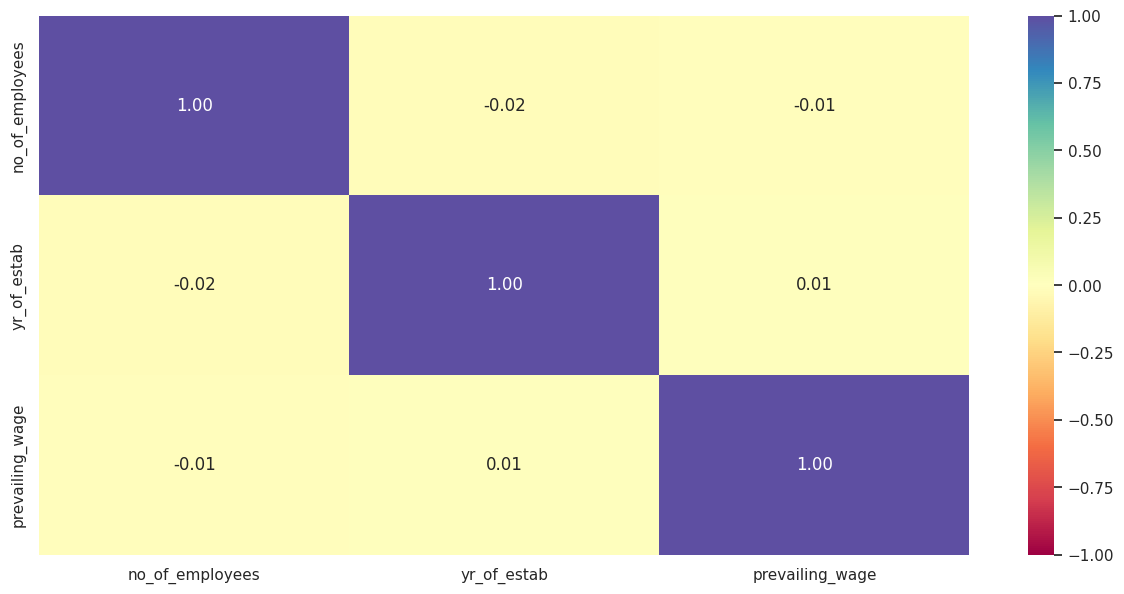

In [0]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- No significant correlation between variables

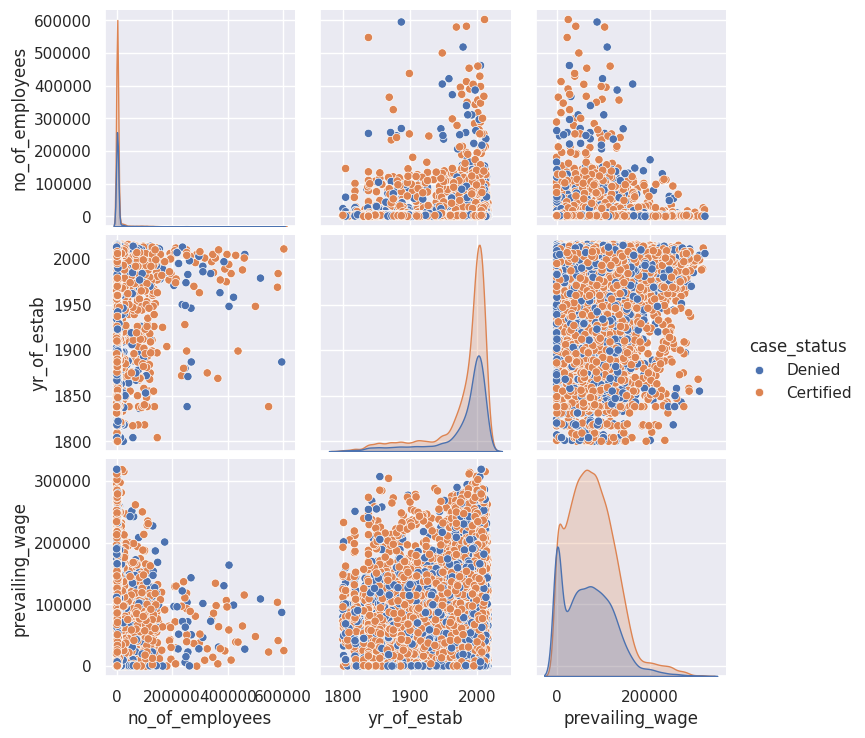

In [0]:
sns.pairplot(data, hue="case_status")

- There are overlaps - no clear distinction in the distribution of variables for Visa denied vs certified

<Axes: xlabel='case_status', ylabel='yr_of_estab'>

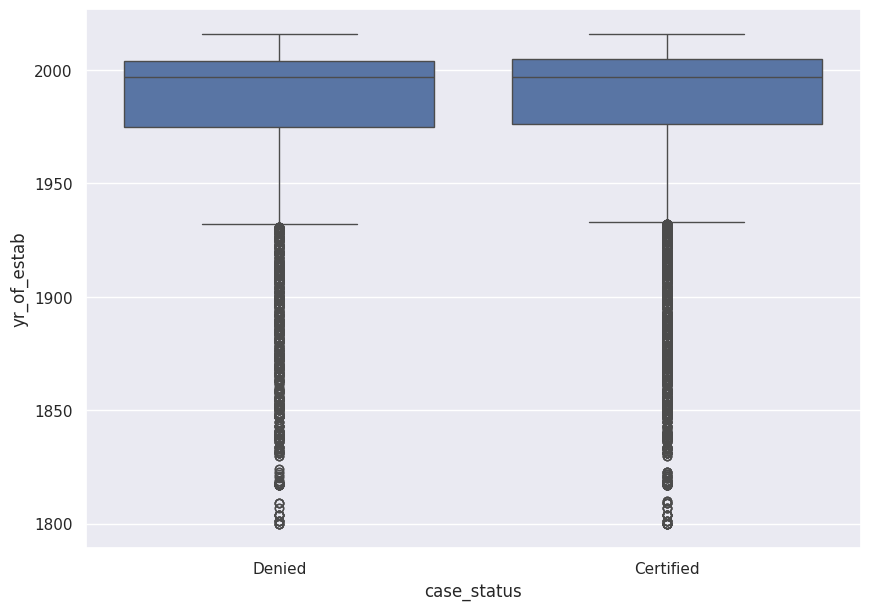

In [0]:
# Visualize the distribution of 'yr_of_estab' across different 'case_status' categories
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="case_status", y="yr_of_estab", data=data, orient="vertical")

- 50% of the companies are established after 1975 and before 2005 with not much clear distinction between denying or certifying visa application
- There are many outliers indicating that many companies have heritage of 100-200 years 

<Axes: xlabel='case_status', ylabel='prevailing_wage'>

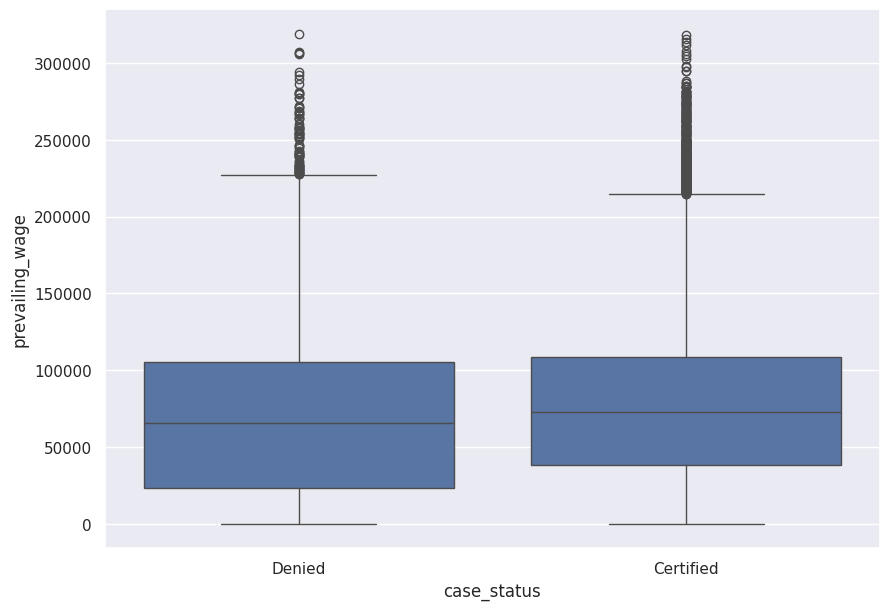

In [0]:
# Visualize the distribution of 'prevailing_wage' across different 'case_status' categories
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="case_status", y="prevailing_wage", data=data, orient="vertical")

- Median wage for Certified Visa applicant is slighly higher than Denied applicants

In [0]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


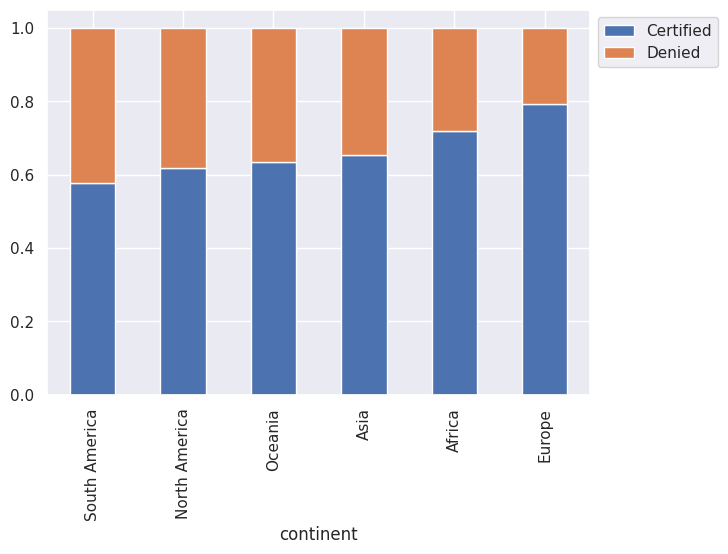

In [0]:
# Visualize the distribution of 'continent' across different 'case_status' categories
stacked_barplot(data, "continent", "case_status")

- Most of the Visa applicantions are certified in Europe, indicating more chances of Visa certification
- South america has 58% of Visa applicant certified which is less than other continent

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


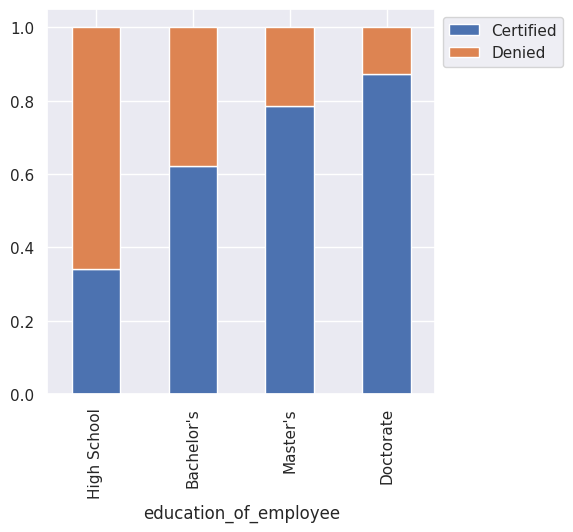

In [0]:
# Visualize the distribution of 'education_of_employee' across different 'case_status' categories
stacked_barplot(data, "education_of_employee", "case_status")

- Higher the education, higher the chances of Visa certification, doctorate degree with 90% chances of approval

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


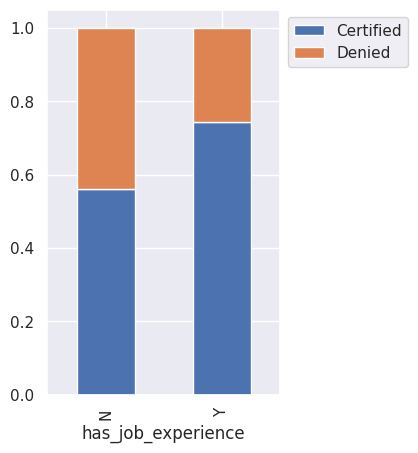

In [0]:
# Visualize the distribution of 'has_job_experience' across different 'case_status' categories
stacked_barplot(data, "has_job_experience", "case_status")

- Experienced candidates are preferred over inexperienced

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


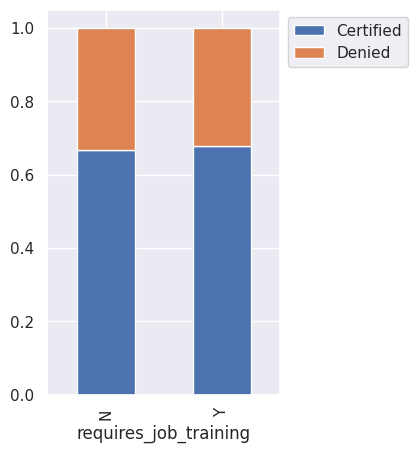

In [0]:
# Visualize the distribution of 'requires_job_training' across different 'case_status' categories
stacked_barplot(data, "requires_job_training", "case_status")

- No clear distinction across case_status
- Mostly 65% of applicants are approved regardless of job_training support

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


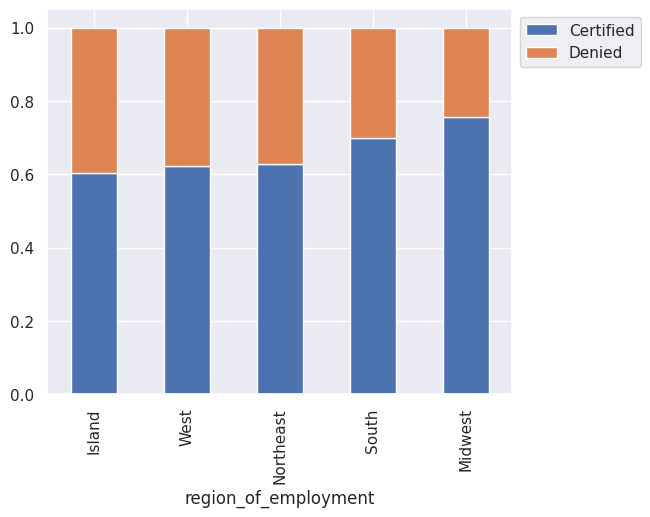

In [0]:
# Visualize the distribution of 'region_of_employment' across different 'case_status' categories
stacked_barplot(data, "region_of_employment", "case_status")

- Midwest region has more chances, followed by South in Visa certified

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


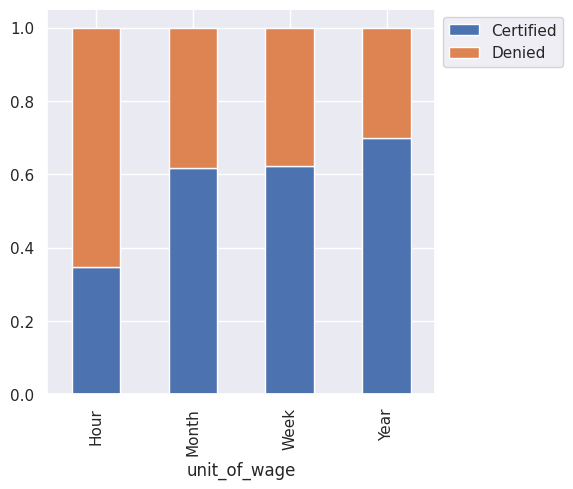

In [0]:
# Visualize the distribution of 'unit_of_wage' across different 'case_status' categories
stacked_barplot(data, "unit_of_wage", "case_status")

- Yearly wages have more certifying chances, followed by monthly and weekly
- Hourly wages are mostly denied

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


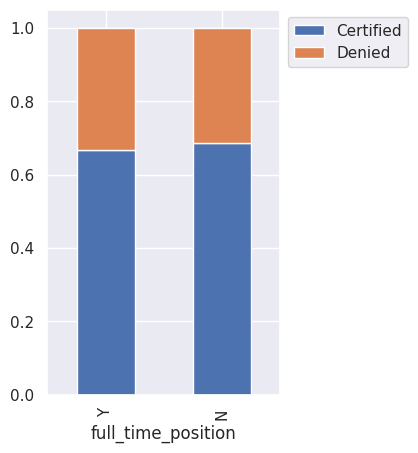

In [0]:
# Visualize the distribution of 'full_time_position' across different 'case_status' categories
stacked_barplot(data, "full_time_position", "case_status")

- Not much difference, mostly 65% are always certified regardless of full-time/part-time status

## Data Preprocessing

In [0]:
df = data.copy()

In [0]:
# Check the nagative values observed in EDA and Data Overview in Employees count
display(df[df['no_of_employees'] <= 0])

continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
Europe,Master's,N,N,-25,1980,Northeast,39452.99,Year,Y,Certified
Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.14,Year,Y,Denied
South America,Master's,Y,N,-17,2002,South,129701.94,Year,Y,Certified
Asia,Master's,Y,N,-26,2005,Midwest,112799.46,Year,Y,Certified
Asia,Bachelor's,N,N,-14,2013,South,103.97,Hour,Y,Denied
Asia,Bachelor's,Y,N,-26,1923,West,5247.32,Year,Y,Denied
Europe,Doctorate,N,N,-25,1998,Midwest,141435.95,Year,Y,Certified
Asia,High School,N,N,-14,2000,Midwest,58488.5,Year,Y,Denied
Asia,Bachelor's,Y,Y,-26,2006,South,115005.61,Year,Y,Certified
Asia,Master's,N,N,-11,2009,Midwest,38457.51,Year,Y,Certified


In [0]:
# Percentage of corrupt entries in no_of_employees
employee_error = (df['no_of_employees'] <= 0).mean() * 100
print(f"{employee_error:.2f}% of rows have no_of_employees <= 0")

0.13% of rows have no_of_employees <= 0


- We can drop the rows containing negative values to not compromize on model's prediction as currently no context is available on corrupt entries 

In [0]:
# Dropping the negative values
df = df[df['no_of_employees'] >= 0]

# Reindex dataframe
df.reset_index(drop=True, inplace=True)

In [0]:
employee_error = (df['no_of_employees'] <= 0).mean() * 100
print(f"{employee_error:.2f}% of rows have no_of_employees <= 0")

0.00% of rows have no_of_employees <= 0


- The employee_count with negative values are removed

In [0]:
for feature in df.columns: # Loop through all columns in the dataframe
    if df[feature].dtype == 'object': # Only apply for columns with categorical strings
        df[feature] = pd.Categorical(df[feature])# Replace strings with an integer
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25447 entries, 0 to 25446
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25447 non-null  category
 1   education_of_employee  25447 non-null  category
 2   has_job_experience     25447 non-null  category
 3   requires_job_training  25447 non-null  category
 4   no_of_employees        25447 non-null  int64   
 5   yr_of_estab            25447 non-null  int64   
 6   region_of_employment   25447 non-null  category
 7   prevailing_wage        25447 non-null  float64 
 8   unit_of_wage           25447 non-null  category
 9   full_time_position     25447 non-null  category
 10  case_status            25447 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 796.7 KB


In [0]:
print(df.continent.value_counts())
print(df.education_of_employee.value_counts())
print(df.has_job_experience.value_counts())
print(df.requires_job_training.value_counts())
print(df.region_of_employment.value_counts())
print(df.unit_of_wage.value_counts())
print(df.full_time_position.value_counts())
print(df.case_status.value_counts())


continent
Asia             16840
Europe            3727
North America     3287
South America      851
Africa             550
Oceania            192
Name: count, dtype: int64
education_of_employee
Bachelor's     10220
Master's        9622
High School     3416
Doctorate       2189
Name: count, dtype: int64
has_job_experience
Y    14786
N    10661
Name: count, dtype: int64
requires_job_training
N    22498
Y     2949
Name: count, dtype: int64
region_of_employment
Northeast    7189
South        7006
West         6578
Midwest      4299
Island        375
Name: count, dtype: int64
unit_of_wage
Year     22933
Hour      2153
Week       272
Month       89
Name: count, dtype: int64
full_time_position
Y    22741
N     2706
Name: count, dtype: int64
case_status
Certified    17001
Denied        8446
Name: count, dtype: int64


In [0]:
replaceStruct = {
                "education_of_employee": 
                    {
                        "High School": 1, 
                        "Bachelor's": 2 ,
                        "Master's": 3 ,
                        "Doctorate":4
                    },
                "has_job_experience": 
                    {
                        "N": 0, 
                        "Y": 1
                    },
                "requires_job_training": 
                    {
                        "N": 0, 
                        "Y": 1
                    },
                "full_time_position": 
                    {
                        "N": 0, 
                        "Y": 1
                    },
                "case_status": 
                    {
                        "Denied": 0, 
                        "Certified": 1
                    }
                }
oneHotCols=["education_of_employee","has_job_experience","requires_job_training","full_time_position", "case_status"]
           # "continent", "region_of_employment", "unit_of_wage"]


In [0]:
# One-hot encode nominal categories

import warnings
warnings.filterwarnings("ignore")

df=df.replace(replaceStruct)

for col in replaceStruct.keys():
    df[col] = df[col].astype(int)

df = pd.get_dummies(df, columns=["continent", "region_of_employment", "unit_of_wage"], dtype=int, drop_first=False)

df.head(10)


,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,1,0,0,14513,2007,592.203,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0
1,3,1,0,2412,2002,83425.650,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1
2,2,0,1,44444,2008,122996.860,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
3,2,0,0,98,1897,83434.030,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
4,3,1,0,1082,2005,149907.390,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
5,3,1,0,2339,2012,78252.140,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
6,2,0,0,4985,1994,53635.390,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
7,2,1,0,3035,1924,418.230,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0
8,2,0,0,4810,2012,74362.190,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
9,4,1,0,2251,1995,67514.760,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1


In [0]:
# Separate features and target variable for modeling
X = df.drop(["case_status"], axis=1)
y = df["case_status"]

In [0]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15267, 22) (5090, 22) (5090, 22)


## Model Building

### Initial Model Building

In [0]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    return {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred)
    }

In [0]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Original class distribution:", Counter(y_train))

# Apply SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_smote))

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print("After Undersampling:", Counter(y_train_under))


Original class distribution: Counter({1: 10199, 0: 5068})
After SMOTE: Counter({0: 10199, 1: 10199})
After Undersampling: Counter({0: 5068, 1: 5068})


In [0]:
# Defining models

models = [] 

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))


#### Model Building - Original data

In [0]:
cv_results_original = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
val_scores_original = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    cv_results_original.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    val_scores_original.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.32127917375877
Random forest: 83.8807710430911
GBM: 87.47910836723115
Adaboost: 89.06746867457136
Xgboost: 84.73379395897643
dtree: 73.51693448345499

Validation Performance:



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Bagging: 0.7797706556895031


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Random forest: 0.8412231696559835


...

GBM: 0.8794472214054689


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Adaboost: 0.8950308732725669
Xgboost: 0.8559247280211703


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

dtree: 0.7453690091149662


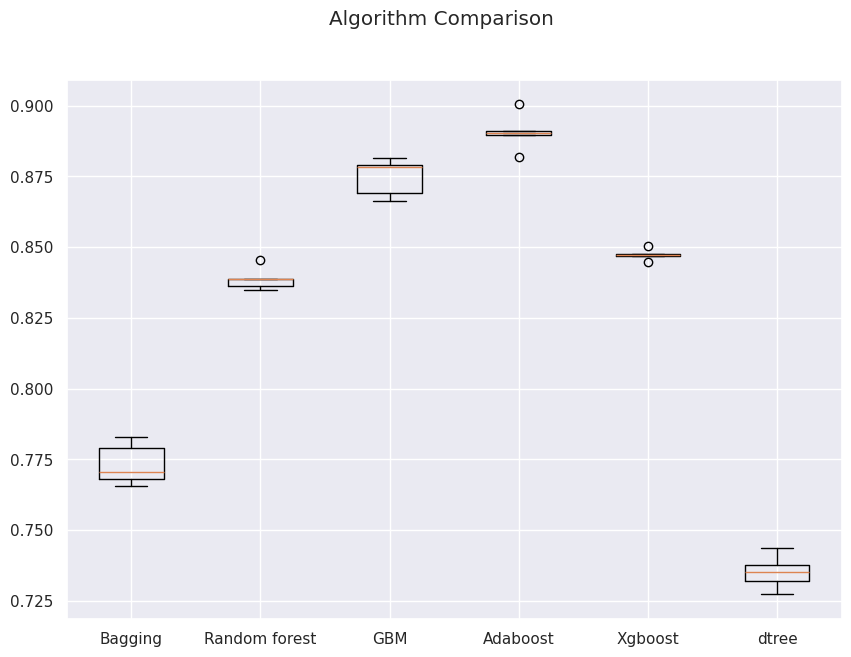

In [0]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(cv_results_original)
ax.set_xticklabels(names)

plt.show()

- Best performed in Original data - **Adaboost** followed by **GBM** and **Xgboost**

#### Model Building - Undersampled data

In [0]:
cv_results_under = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
val_scores_under = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_under, y=y_train_under, scoring=scoring, cv=kfold
    )
    cv_results_under.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_under, y_train_under)
    scores = recall_score(y_val, model.predict(X_val))
    val_scores_under.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 61.168264241390524
Random forest: 66.83168124052018
GBM: 70.342977193915
Adaboost: 71.48783759840029
Xgboost: 67.56148374874171
dtree: 62.52987299232269

Validation Performance:



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Bagging: 0.6151132019994119


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Random forest: 0.6856806821523082


...

GBM: 0.7209644222287562


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Adaboost: 0.7241987650690973
Xgboost: 0.683622463981182


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

dtree: 0.6333431343722434


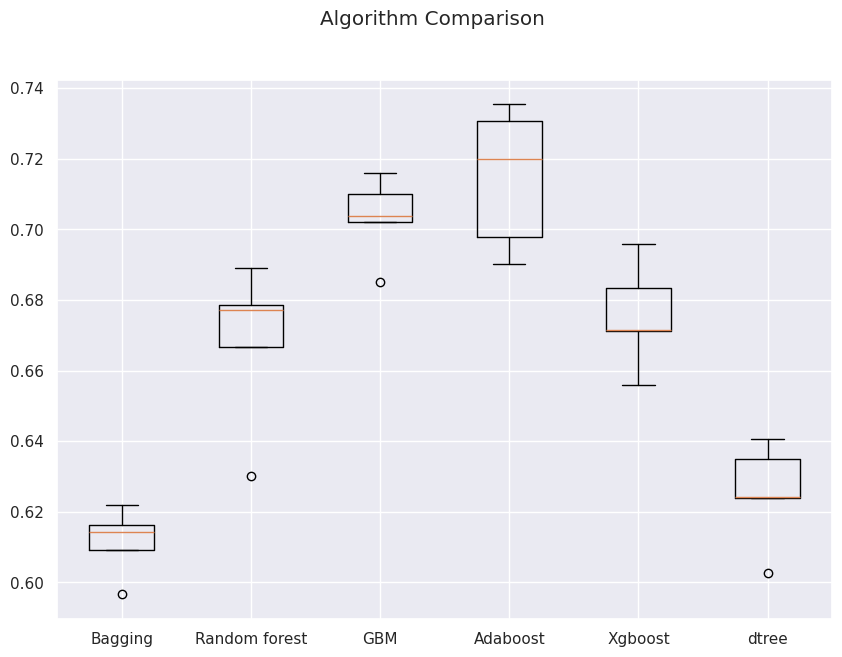

In [0]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(cv_results_under)
ax.set_xticklabels(names)

plt.show()

- Best performed in Original data - **Adaboost** followed by **GBM** and **Xgboost**

#### Model Building - Oversampled data

In [0]:
cv_results_smote = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
val_scores_smote = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_smote, y=y_train_smote, scoring=scoring, cv=kfold
    )
    cv_results_smote.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_smote, y_train_smote)
    scores = recall_score(y_val, model.predict(X_val))
    val_scores_smote.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 74.95837059689006
Random forest: 80.82166382982817
GBM: 83.24337189510429
Adaboost: 78.93895027358664
Xgboost: 83.0375472405735
dtree: 73.43865216513285

Validation Performance:



Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Bagging: 0.7691855336665686


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Random forest: 0.822993237283152


...

GBM: 0.8403410761540724


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Adaboost: 0.785357247868274
Xgboost: 0.8453396059982358


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

dtree: 0.7465451337841811


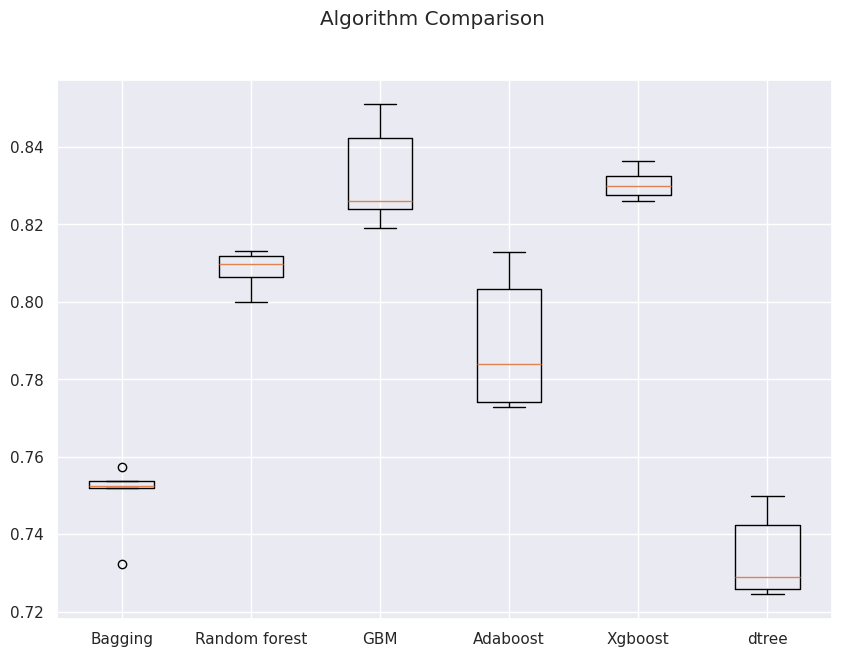

In [0]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(cv_results_smote)
ax.set_xticklabels(names)

plt.show()

- Best performed in Original data - **GBM** followed by **XGBoost** and **Randomforest**

In [0]:
df_val_recall = pd.DataFrame({
    'Model': names,
    'Original': val_scores_original,
    'SMOTE': val_scores_smote,
    'Undersampled': val_scores_under
})

display(df_val_recall)


Model,Original,SMOTE,Undersampled
Bagging,0.7797706556895031,0.7691855336665686,0.6151132019994119
Random forest,0.8412231696559835,0.822993237283152,0.6856806821523082
GBM,0.8794472214054689,0.8403410761540724,0.7209644222287562
Adaboost,0.8950308732725669,0.785357247868274,0.7241987650690973
Xgboost,0.8559247280211703,0.8453396059982358,0.683622463981182
dtree,0.7453690091149662,0.7465451337841811,0.6333431343722434


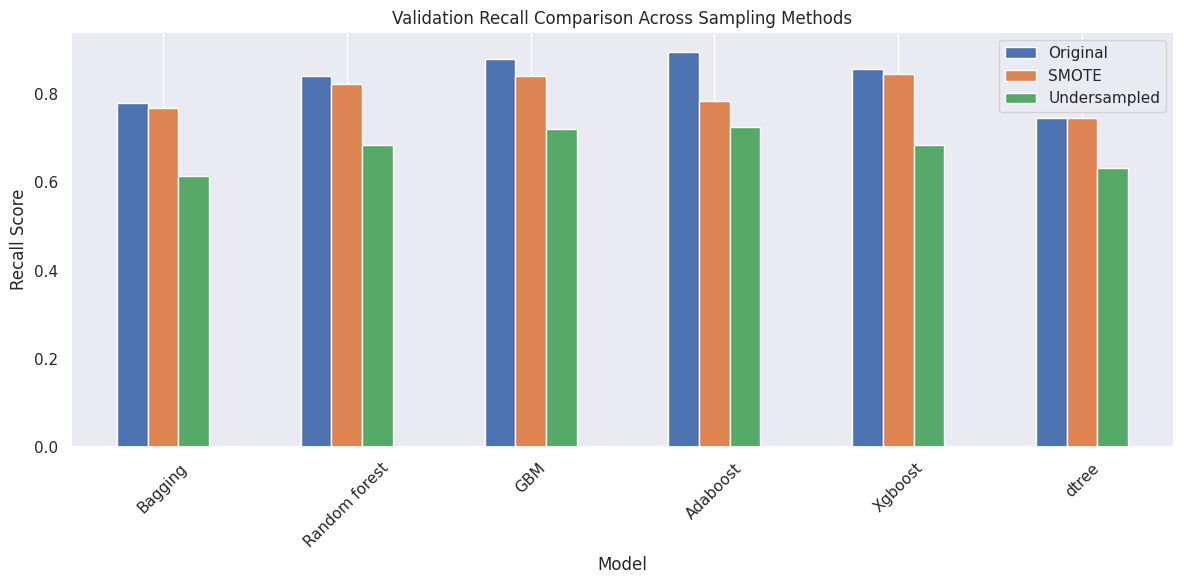

In [0]:
df_val_recall.set_index("Model").plot(kind="bar", figsize=(12, 6), title="Validation Recall Comparison Across Sampling Methods")
plt.ylabel("Recall Score")
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Choosing best Sampling Models
- Best out of all orginal, oversampled and undersampled is Adaboost, XGBoost and GBM
  - XGBoost showed the balanced performance across Original and Oversampled data
  - XGBoost and GBM permed best in Oversampled dataset
  - AdaBoost performed best in Original dataset
  - GBM and Adaboost was strong under undersampled distribution

## Hyperparameter Tuning

**We will tune Adaboost, xgboost and gradientboost-GBM models using GridSearchCV and RandomizedSearchCV. We will also compare the performance and time taken by methods - grid search**

In [0]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [0]:
# XGBoost Classifier 

# verbosity off to avoid logs
model = XGBClassifier(random_state=1,eval_metric='logloss', verbosity=0)

#Parameter grid to pass in GridSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]
            }


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1, verbose= 1)

#Fitting parameters in GridSeachCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Best parameters are {'gamma': 0, 'learning_rate': 0.01, 'max_depth': np.int64(1), 'n_estimators': np.int64(50), 'reg_lambda': 5, 'scale_pos_weight': 2, 'subsample': 0.8} with CV score=1.0:


In [0]:
# building model with best parameters
xgb_tuned1 = XGBClassifier(
    random_state=1,
    n_estimators=50,
    scale_pos_weight=2,
    subsample=0.8,
    learning_rate=0.01,
    gamma=0,
    eval_metric="logloss",
    reg_lambda=5,
    max_depth=1,
)

# Fit the model on training data
xgb_tuned1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [0]:
# Calculating different metrics on train set
xgboost_grid_train = model_performance_classification_sklearn(
    xgb_tuned1, X_train, y_train
)
print("Training performance:")
xgboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


In [0]:
# Calculating different metrics on validation set
xgboost_grid_val = model_performance_classification_sklearn(xgb_tuned1, X_val, y_val)
print("Validation performance:")
xgboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


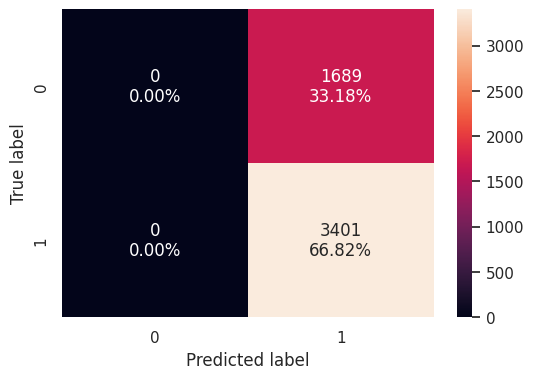

In [0]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned1, X_val, y_val)

In [0]:
# XGBoost with Randomized Search

xgb_model = XGBClassifier(random_state=1, eval_metric='logloss', verbosity=0)

# Define hyperparameter distribution
param_dist = {
    'n_estimators': np.arange(50, 200, 25),
    'scale_pos_weight': [2, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0, 1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'max_depth': np.arange(1, 6),
    'reg_lambda': [1, 5, 10, 20]
}

# Scoring metric
scorer = metrics.make_scorer(metrics.recall_score)

# Randomized search setup
random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    scoring=scorer,
    n_iter=50,  # You can change this for more/less thorough search
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit search
random_cv.fit(X_train, y_train)

# Output best configuration
print("Best parameters found:", random_cv.best_params_)
print("Best recall score:", random_cv.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Best parameters found: {'subsample': 1.0, 'scale_pos_weight': 5, 'reg_lambda': 20, 'n_estimators': np.int64(175), 'max_depth': np.int64(4), 'learning_rate': 0.01, 'gamma': 0}
Best recall score: 1.0


In [0]:
# building model with best parameters
xgb_random_best = XGBClassifier(
    random_state=1,
    n_estimators=175,
    scale_pos_weight=5,
    subsample=1,
    learning_rate=0.01,
    gamma=0,
    eval_metric="logloss",
    reg_lambda=20,
    max_depth=4,
)

# Fit the model on training data
xgb_random_best.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=175, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost RandomizedSearch Performance (Train vs Validation):


XGBoost RandomizedSearch - Training,XGBoost RandomizedSearch - Validation
0.6680421824850986,0.6681728880157171
1.0,1.0
0.6680421824850986,0.6681728880157171
0.8009895547003848,0.8010835001766576


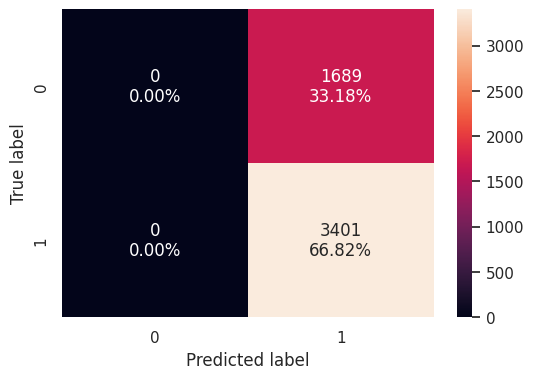

In [0]:
# Evaluate both
xgb_random_train = model_performance_classification_sklearn(xgb_random_best, X_train, y_train)
xgb_random_val = model_performance_classification_sklearn(xgb_random_best, X_val, y_val)

# Combine into one DataFrame
xgb_random_combined = pd.concat(
    [xgb_random_train.T, xgb_random_val.T],
    axis=1
)
xgb_random_combined.columns = ["XGBoost RandomizedSearch - Training", "XGBoost RandomizedSearch - Validation"]

# Display both together
print("XGBoost RandomizedSearch Performance (Train vs Validation):")
display(xgb_random_combined)

# Confusion Matrix for validation
confusion_matrix_sklearn(xgb_random_best, X_val, y_val)

RandomizedSearchCV completed significantly faster than GridSearchCV and returned similar performance metrics. Thus, it is recommended for faster iteration in future tuning workflows

##### Performing same GridSearch for Adaboost and Gradientboost

In [0]:
# GradientBoost model tuning 
gbm = GradientBoostingClassifier(random_state=1)

# Define parameter distributions for randomized search
param_dist_gbm = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

# Define scoring metric
scorer = metrics.make_scorer(metrics.recall_score)

# Set up RandomizedSearchCV
random_cv_gbm = RandomizedSearchCV(
    estimator=gbm,
    param_distributions=param_dist_gbm,
    scoring=scorer,
    n_iter=20,          # You can increase this if more time/computation is available
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit to training data
random_cv_gbm.fit(X_train, y_train)

# Output the best params and score
print("Best Gradient Boosting parameters (RandomizedSearchCV):", random_cv_gbm.best_params_)
print("Best CV Recall Score (Gradient Boosting):", random_cv_gbm.best_score_)

# Save best model
gbm_random_best = random_cv_gbm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Best Gradient Boosting parameters (RandomizedSearchCV): {'subsample': 0.8, 'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': 3, 'learning_rate': 0.01}
Best CV Recall Score (Gradient Boosting): 1.0


In [0]:
# building model with best parameters
gbm_tuned1 = GradientBoostingClassifier(
    learning_rate=0.01, 
    max_depth=3, 
    min_samples_leaf=3, 
    min_samples_split=5, 
    n_estimators=50, 
    subsample=0.8
)

# Fit the model on training data
gbm_tuned1.fit(X_train, y_train)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

GradientBoostingClassifier(learning_rate=0.01, min_samples_leaf=3,
                           min_samples_split=5, n_estimators=50, subsample=0.8)

In [0]:
# Calculating different metrics on train set
gbmboost_grid_train = model_performance_classification_sklearn(
    gbm_tuned1, X_train, y_train
)
print("Training performance:")
gbmboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


In [0]:
# Calculating different metrics on validation set
gbmboost_grid_val = model_performance_classification_sklearn(gbm_tuned1, X_val, y_val)
print("Validation performance:")
gbmboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


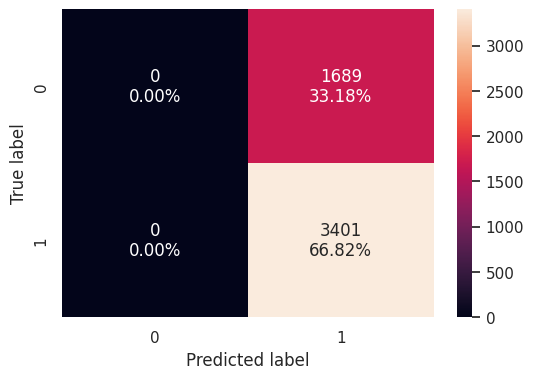

In [0]:
# creating confusion matrix
confusion_matrix_sklearn(gbm_tuned1, X_val, y_val)

In [0]:
# Adaboost model tuning
ada = AdaBoostClassifier(random_state=1)

# Define parameter distributions for randomized search
param_dist_ada = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# Scoring metric
scorer = metrics.make_scorer(metrics.recall_score)

# Set up RandomizedSearchCV
random_cv_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    scoring=scorer,
    n_iter=20,  # You can increase for better exploration
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit to training data
random_cv_ada.fit(X_train, y_train)

# Output the best params and score
print("Best AdaBoost parameters (RandomizedSearchCV):", random_cv_ada.best_params_)
print("Best CV Recall Score (AdaBoost):", random_cv_ada.best_score_)

# Save the best estimator
ada_random_best = random_cv_ada.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Best AdaBoost parameters (RandomizedSearchCV): {'n_estimators': 50, 'learning_rate': 0.01}
Best CV Recall Score (AdaBoost): 1.0


In [0]:
# building model with best parameters
adaboost_tuned1 = AdaBoostClassifier(
    learning_rate=0.01,  
    n_estimators=50
)

# Fit the model on training data
adaboost_tuned1.fit(X_train, y_train)

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

AdaBoostClassifier(learning_rate=0.01)

In [0]:
# Calculating different metrics on train set
adaboost_grid_train = model_performance_classification_sklearn(
    adaboost_tuned1, X_train, y_train
)
print("Training performance:")
adaboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


In [0]:
# Calculating different metrics on validation set
adaboost_grid_val = model_performance_classification_sklearn(adaboost_tuned1, X_val, y_val)
print("Validation performance:")
adaboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


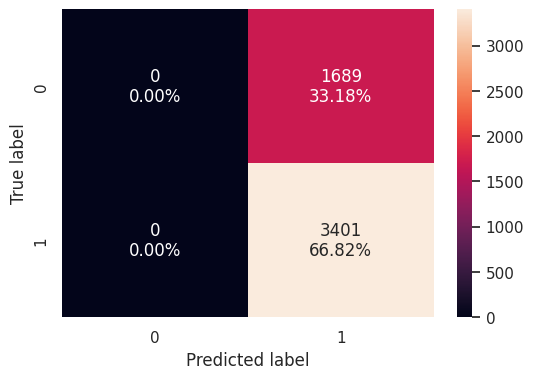

In [0]:
# creating confusion matrix
confusion_matrix_sklearn(adaboost_tuned1, X_val, y_val)

In [0]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        xgboost_grid_train.T,
        xgb_random_train.T,
        gbmboost_grid_train.T,
        adaboost_grid_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "XGBoost Tuned with Grid search",
    "XGBoost Tuned with Randomized Search",
    "GradientBoost Tuned with Randomized search",
    "Adaboost Tuned with Randomized search"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,XGBoost Tuned with Grid search,XGBoost Tuned with Randomized Search,GradientBoost Tuned with Randomized search,Adaboost Tuned with Randomized search
Accuracy,0.668,0.668,0.668,0.668
Recall,1.000,1.000,1.000,1.000
Precision,0.668,0.668,0.668,0.668
F1,0.801,0.801,0.801,0.801


In [0]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        xgboost_grid_val.T,
        xgb_random_val.T,
        gbmboost_grid_val.T,
        adaboost_grid_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "XGBoost Tuned with Grid search",
    "XGBoost Tuned with Randomized search",
    "GradientBoost Tuned with Randomized search",
    "Adaboost Tuned with Randomized search"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,XGBoost Tuned with Grid search,XGBoost Tuned with Randomized search,GradientBoost Tuned with Randomized search,Adaboost Tuned with Randomized search
Accuracy,0.668,0.668,0.668,0.668
Recall,1.000,1.000,1.000,1.000
Precision,0.668,0.668,0.668,0.668
F1,0.801,0.801,0.801,0.801


In [0]:
# Test set Evaluation
xgb_test_perf = model_performance_classification_sklearn(xgb_tuned1, X_test, y_test)
xgb_test_random_perf = model_performance_classification_sklearn(xgb_random_best, X_test, y_test)
gbm_test_perf = model_performance_classification_sklearn(gbm_tuned1, X_test, y_test)
adaboost_test_perf = model_performance_classification_sklearn(adaboost_tuned1, X_test, y_test)

models_test_comp_df = pd.concat(
    [
        xgb_test_perf.T,
        xgb_test_random_perf.T,
        gbm_test_perf.T,
        adaboost_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "XGBoost Tuned with Grid search",
    "XGBoost Tuned with Randomized search",
    "GradientBoost Tuned with Randomized search",
    "Adaboost Tuned with Randomized search"
]
print("Testing Set performance comparison:")
display(models_test_comp_df)

Testing Set performance comparison:


XGBoost Tuned with Grid search,XGBoost Tuned with Randomized search,GradientBoost Tuned with Randomized search,Adaboost Tuned with Randomized search
0.6681728880157171,0.6681728880157171,0.6681728880157171,0.6681728880157171
1.0,1.0,1.0,1.0
0.6681728880157171,0.6681728880157171,0.6681728880157171,0.6681728880157171
0.8010835001766576,0.8010835001766576,0.8010835001766576,0.8010835001766576


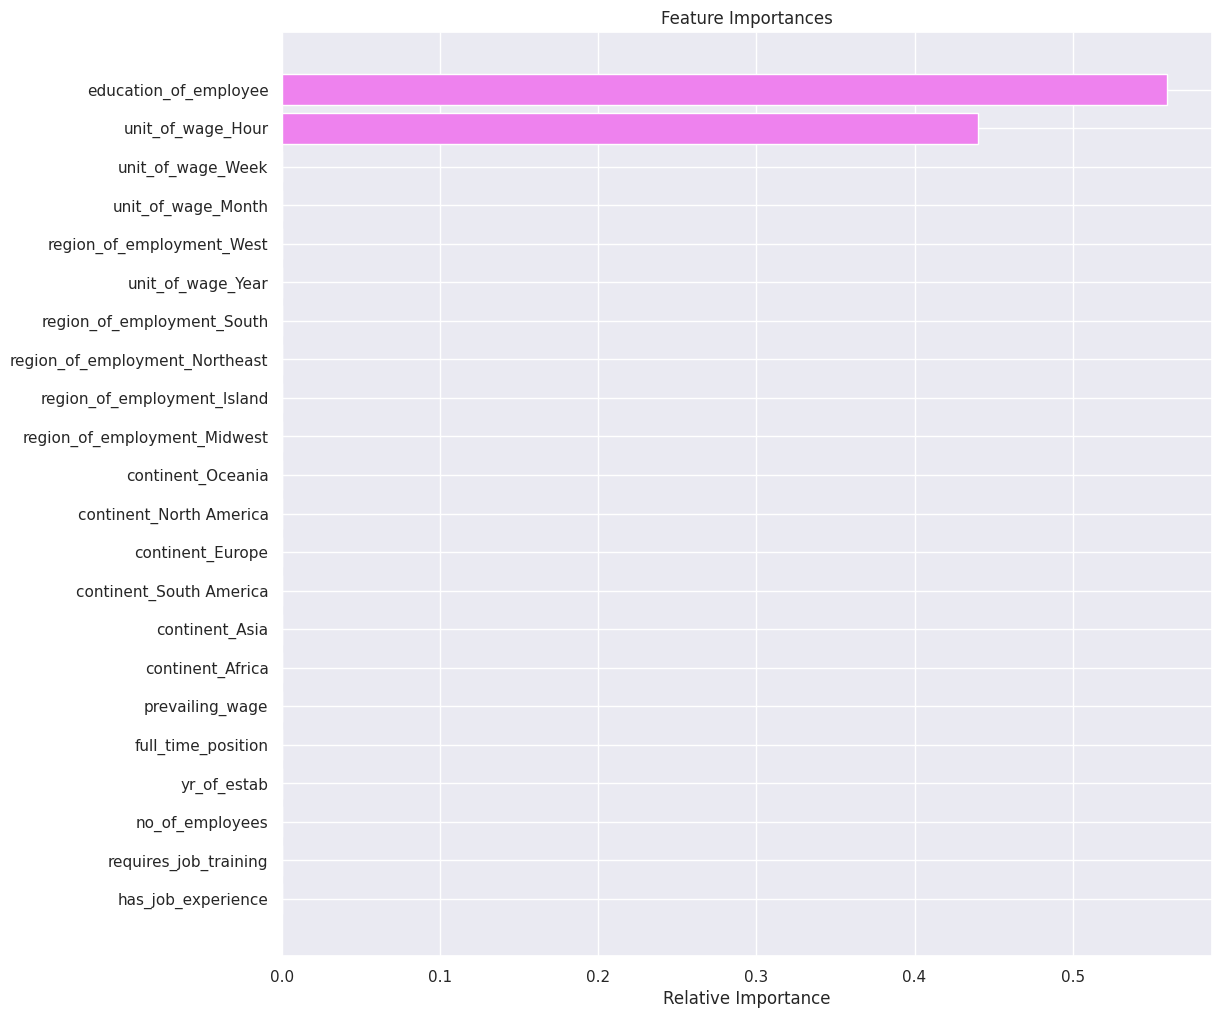

In [0]:
# XGBoost Feature importance for GridSearch
feature_names = X_train.columns
importances = xgb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Most important features are education_od_employee and unit_of_wage (hourly wage impact on Visa application)

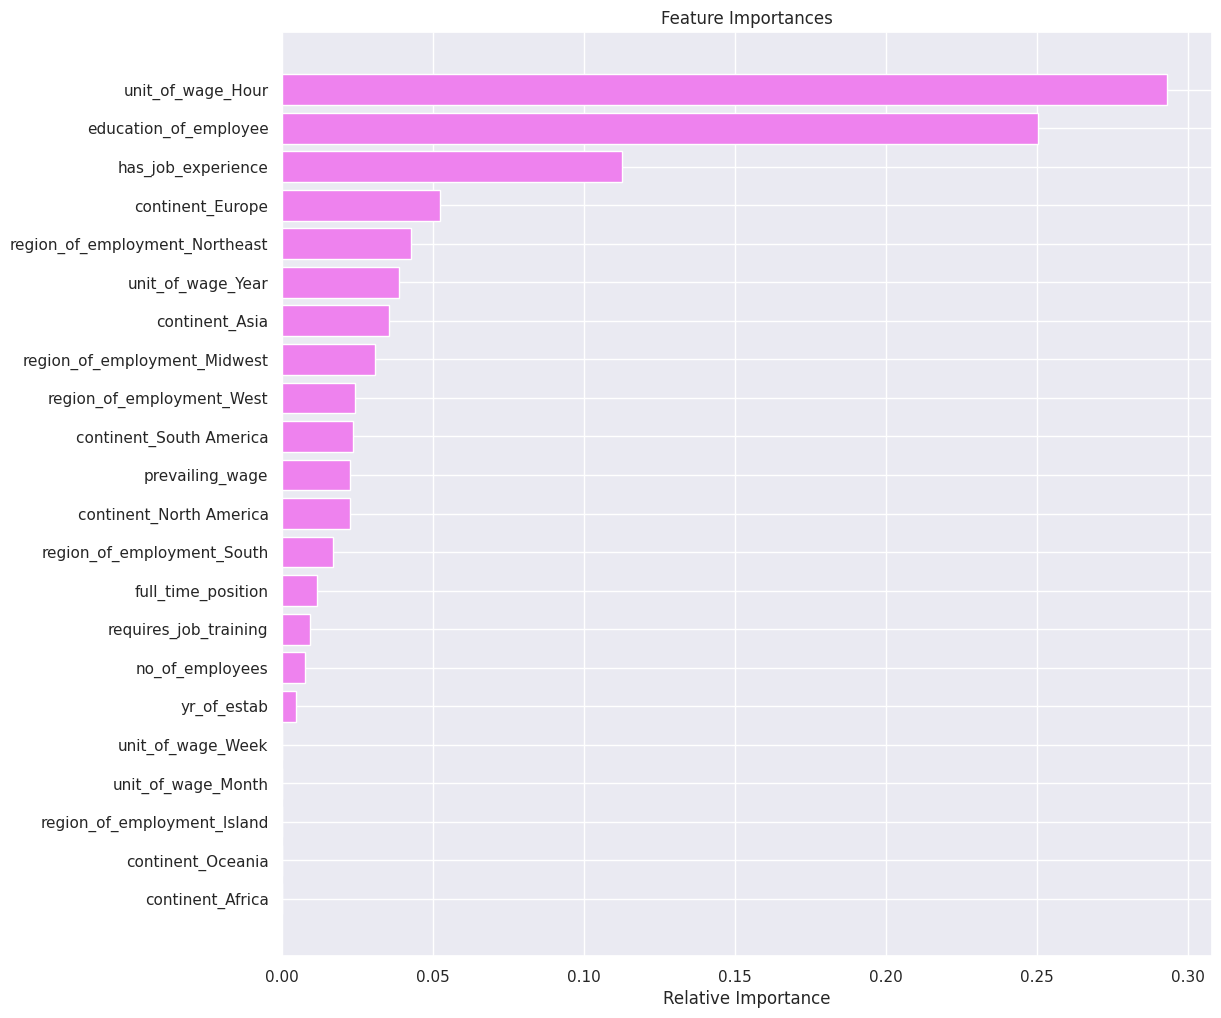

In [0]:
# XGBoost Feature importance for RandomizedSearch
feature_names = X_train.columns
importances = xgb_random_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- XGBoost RandomizedSearch has more feature selection compared to gridsearch

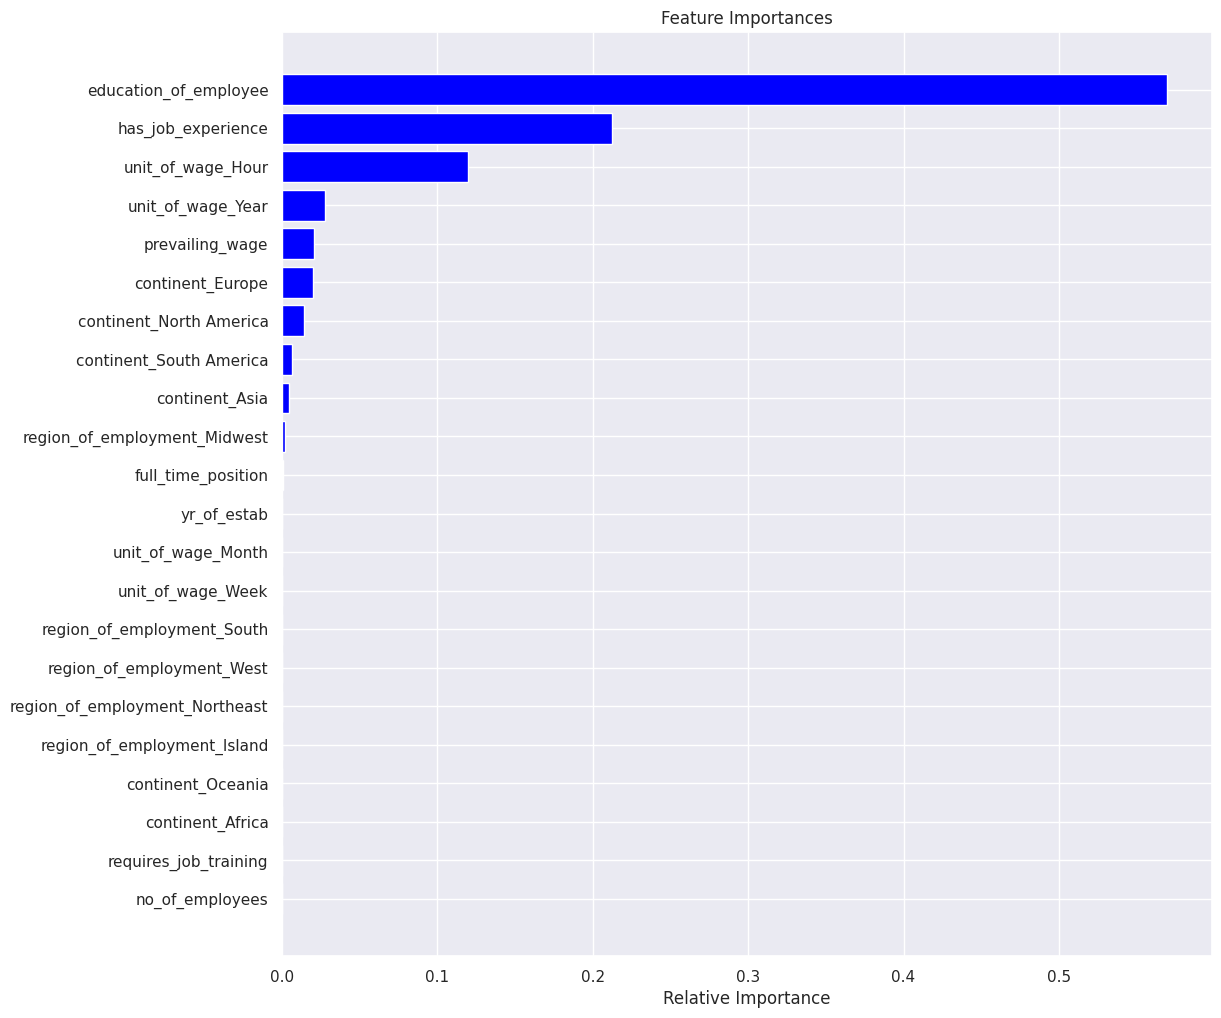

In [0]:
# GradientBoost Feature importance for RandomizedSearch

feature_names = X_train.columns
importances = gbm_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

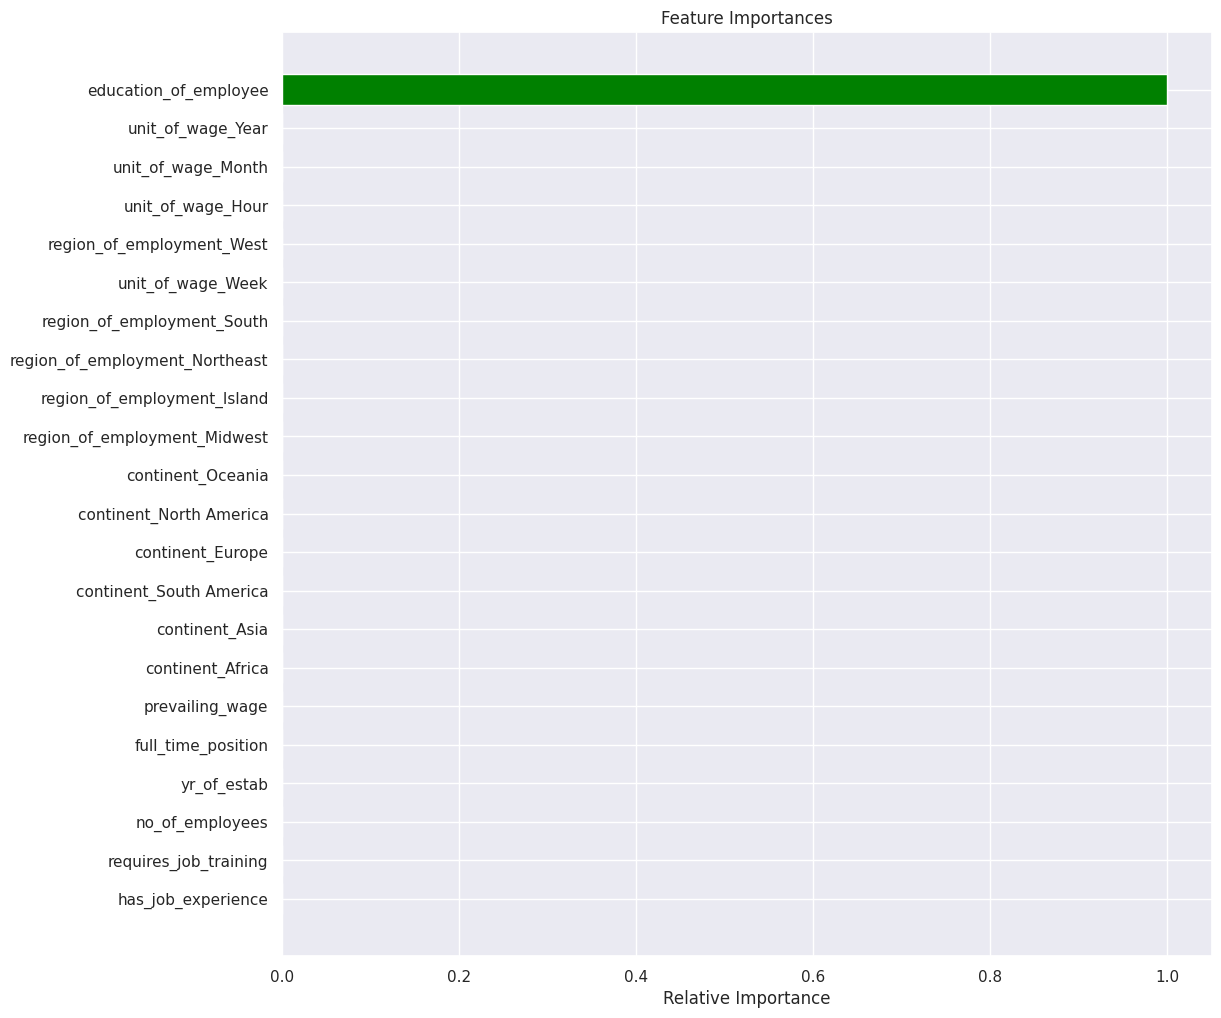

In [0]:
# AdaBoost Feature importance for RandomizedSearch

feature_names = X_train.columns
importances = adaboost_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="green", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Summary
- XGBoost (tuned) delivered the most balanced performance across original, oversampled (SMOTE), and undersampled datasets, making it the most reliable model overall
- AdaBoost showed the best recall under SMOTE, making it ideal if minimizing false negatives is the priority
- Gradient Boosting (GBM) performed reliably on the original dataset and showed more balanced feature importance due to deeper trees (max_depth=3), making it a good candidate for interpretation and business insights
- Key Drivers of Visa Certification (from feature importance):
  - Education level (higher → more likely to be certified)
  - Unit of wage (hourly wages → higher chance of denial)
  - Experienced Employees and prevailing wage also influenced decisions

#### Recommendation:

- All three tuned models performed comparably on validation and test dataset recall. XGBoost is recommended as the primary model due to its fast training, native handling of class imbalance (scale_pos_weight), and regularization features, which make it robust and scalable in production
- Use Gradient Boosting if your primary audience is non-technical stakeholders who need easily explainable features